<a href="https://colab.research.google.com/github/eric56427/er1c/blob/main/Project2_CelebA_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 – CelebA Image Classification
**Machine Learning – Spring 2026**

Dataset: [CelebA (aligned & cropped)](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html)

---
**Sections**
- Setup & Dataset Access
- Shared Utilities (DataGenerators, model builder, evaluation helpers)
- **R1** – Gender Classification
- **R2** – Gender + Age Multi-Target Classification
- **R3** – Smiling Classification with Mouth-Width Metadata
- **R4** – Eye-Width Quartile Classification (Female subset)

## 0 · Dataset Setup (Google Colab via Kaggle API)
Upload your `kaggle.json` key when prompted, then run this cell once to download and unzip the CelebA dataset.

In [ ]:
# ── Install Kaggle CLI and upload credentials ──────────────────────────────
!pip install -q kaggle
from google.colab import files
print('Upload your kaggle.json API key:')
files.upload()                      # select kaggle.json from your machine
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# ── Download & unzip CelebA ────────────────────────────────────────────────
!kaggle datasets download -d jessicali9530/celeba-dataset -p /content/celeba --unzip -q
print('Dataset ready.')

Upload your kaggle.json API key:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
Dataset ready.


### Path Configuration
Edit the variables below if your dataset lives somewhere else (e.g. mounted Google Drive).

In [ ]:
import os

# Root of the unpacked dataset
CELEBA_ROOT  = '/content/celeba'

# Aligned + cropped images
IMG_DIR      = os.path.join(CELEBA_ROOT, 'img_align_celeba', 'img_align_celeba')

# CSV files
ATTR_CSV      = os.path.join(CELEBA_ROOT, 'list_attr_celeba.csv')
LANDMARKS_CSV = os.path.join(CELEBA_ROOT, 'list_landmarks_align_celeba.csv')
PARTITION_CSV = os.path.join(CELEBA_ROOT, 'list_eval_partition.csv')

print('Image dir exists:', os.path.isdir(IMG_DIR))
print('Attr CSV exists :', os.path.isfile(ATTR_CSV))
print('Lmk CSV exists  :', os.path.isfile(LANDMARKS_CSV))
print('Part CSV exists :', os.path.isfile(PARTITION_CSV))

Image dir exists: True
Attr CSV exists : True
Lmk CSV exists  : True
Part CSV exists : True


## 1 · Imports

In [ ]:
import os, random, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Flatten, Dense, Dropout, Concatenate, Input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')
%matplotlib inline
tf.config.run_functions_eagerly(True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU available: []


## 2 · Load CSVs & Build Partitions

In [ ]:
# ── Raw attribute file (all 40 columns + image_id) ─────────────────────────
attr_full = pd.read_csv(ATTR_CSV)

# ── Landmark file ──────────────────────────────────────────────────────────
landmarks = pd.read_csv(LANDMARKS_CSV)

# ── Partition file  (0=train, 1=validation, 2=test in CelebA convention) ───
partition = pd.read_csv(PARTITION_CSV)

# Map -1 → 0 for every attribute column (keep image_id as string)
attr_full.iloc[:, 1:] = attr_full.iloc[:, 1:].replace({-1: 0})

# Merge with partition
df_full = pd.merge(attr_full, partition, on='image_id', how='inner')

# Merge landmarks
df_full = pd.merge(df_full, landmarks, on='image_id', how='inner')

# ── Partition splits ───────────────────────────────────────────────────────
#   CelebA convention: 0=train, 1=validation, 2=test
train_full = df_full[df_full['partition'] == 0].copy()
val_full   = df_full[df_full['partition'] == 1].copy()   # used to tune epochs/sampling
test_full  = df_full[df_full['partition'] == 2].copy()   # final evaluation

print(f'Total  : {len(df_full):>7,}')
print(f'Train  : {len(train_full):>7,}')
print(f'Val    : {len(val_full):>7,}')
print(f'Test   : {len(test_full):>7,}')
print('\nColumns:', list(df_full.columns[:10]), '...')

Total  : 202,599
Train  : 162,770
Val    :  19,867
Test   :  19,962

Columns: ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair'] ...


## 3 · Shared Utilities
### 3.1 DataGenerator (image-only targets)

In [ ]:
class DataGenerator(tf.keras.utils.Sequence):
    """
    Batched image data generator for multi-target binary classification.

    Parameters
    ----------
    df          : DataFrame with 'image_id' and all target columns
    target_cols : list[str]  – column names to use as classification targets
    img_dir     : str        – directory containing the aligned images
    batch_size  : int
    dim         : (height, width) tuple – CelebA aligned = (218, 178)
    n_channels  : int
    shuffle     : bool
    """
    def __init__(self, df, target_cols, img_dir,
                 batch_size=32, dim=(218, 178), n_channels=3, shuffle=False):
        self.df          = df.reset_index(drop=True)
        self.target_cols = target_cols
        self.n_classes   = len(target_cols)
        self.img_dir     = img_dir
        self.batch_size  = batch_size
        self.dim         = dim
        self.n_channels  = n_channels
        self.shuffle     = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        idxs    = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]
        df_temp = self.df.iloc[idxs].reset_index(drop=True)
        return self.__data_generation(df_temp)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, df_temp):
        bs = len(df_temp)
        X  = np.empty((bs, *self.dim, self.n_channels), dtype=np.float32)
        y  = np.empty((bs, self.n_classes), dtype=np.float32)

        for i, row in df_temp.iterrows():
            img_path = os.path.join(self.img_dir, row['image_id'])
            img      = keras_image.load_img(img_path, target_size=self.dim)
            img      = keras_image.img_to_array(img) / 255.0
            X[i]     = img
            y[i]     = row[self.target_cols].values.astype(np.float32)

        return X, y

### 3.2 DataGeneratorWithMeta (image + scalar metadata feature)

In [ ]:
class DataGeneratorWithMeta(tf.keras.utils.Sequence):
    """
    Like DataGenerator but returns a second input array containing one
    normalised scalar metadata feature (e.g. a quartile 0-3 scaled to 0-1).
    Used for R3b and R4 dual-input models.

    Parameters
    ----------
    meta_col : str – column name of the scalar metadata feature in df
    """
    def __init__(self, df, target_cols, meta_col, img_dir,
                 batch_size=32, dim=(218, 178), n_channels=3, shuffle=False):
        self.df          = df.reset_index(drop=True)
        self.target_cols = target_cols
        self.n_classes   = len(target_cols)
        self.meta_col    = meta_col
        self.img_dir     = img_dir
        self.batch_size  = batch_size
        self.dim         = dim
        self.n_channels  = n_channels
        self.shuffle     = shuffle
        # Normalise metadata feature to [0, 1]
        meta_vals        = self.df[meta_col].values.astype(np.float32)
        self.meta_min    = meta_vals.min()
        self.meta_max    = meta_vals.max()
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        idxs    = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]
        df_temp = self.df.iloc[idxs].reset_index(drop=True)
        return self.__data_generation(df_temp)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, df_temp):
        bs   = len(df_temp)
        X_img  = np.empty((bs, *self.dim, self.n_channels), dtype=np.float32)
        X_meta = np.empty((bs, 1), dtype=np.float32)
        y      = np.empty((bs, self.n_classes), dtype=np.float32)

        rng = self.meta_max - self.meta_min
        rng = rng if rng != 0 else 1.0   # avoid division by zero

        for i, row in df_temp.iterrows():
            img_path   = os.path.join(self.img_dir, row['image_id'])
            img        = keras_image.load_img(img_path, target_size=self.dim)
            img        = keras_image.img_to_array(img) / 255.0
            X_img[i]   = img
            X_meta[i]  = (float(row[self.meta_col]) - self.meta_min) / rng
            y[i]       = row[self.target_cols].values.astype(np.float32)

        return (X_img, X_meta), y

### 3.3 Model Builders & Evaluation Helpers

In [ ]:
# ── Single-input (image only) VGG16 model ─────────────────────────────────
def build_model(n_classes, img_shape=(218, 178, 3), lr=1e-4):
    """
    VGG16 feature extractor + custom classifier head.
    n_classes == 1  → binary classification (single sigmoid neuron)
    n_classes  > 1  → multi-target binary (n sigmoid neurons)
    """
    base = VGG16(input_shape=img_shape, include_top=False, weights='imagenet')
    base.trainable = False

    model = tf.keras.Sequential([
        base,
        Flatten(),
        Dense(1024, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='sigmoid')
    ])
    model.compile(
        optimizer=SGD(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Dual-input (image + scalar metadata) VGG16 model ─────────────────────
def build_dual_input_model(n_classes, img_shape=(218, 178, 3), lr=1e-4):
    """
    Two input branches:
      1) Image  → VGG16 (frozen) → Flatten → Dense(1024)
      2) Scalar → Dense(16)
    Branches are concatenated then passed through a final sigmoid head.
    """
    # Image branch
    base       = VGG16(input_shape=img_shape, include_top=False, weights='imagenet')
    base.trainable = False
    img_input  = Input(shape=img_shape, name='image_input')
    x          = base(img_input, training=False)
    x          = Flatten()(x)
    x          = Dense(1024, activation='relu')(x)
    x          = Dropout(0.3)(x)

    # Metadata branch
    meta_input = Input(shape=(1,), name='meta_input')
    m          = Dense(16, activation='relu')(meta_input)

    # Merge & output
    merged  = Concatenate()([x, m])
    merged  = Dense(256, activation='relu')(merged)
    output  = Dense(n_classes, activation='sigmoid')(merged)

    model = Model(inputs=[img_input, meta_input], outputs=output)
    model.compile(
        optimizer=SGD(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Collect all true labels & predictions from a generator ────────────────
def get_predictions(model, generator, n_classes, has_meta=False):
    """
    Returns (y_true, y_pred_prob) as numpy arrays of shape (N, n_classes).
    """
    y_true_list, y_pred_list = [], []
    for batch_x, batch_y in generator:
        preds = model.predict(batch_x, verbose=0)
        y_true_list.append(batch_y)
        y_pred_list.append(preds)
    y_true = np.vstack(y_true_list)
    y_pred = np.vstack(y_pred_list)
    return y_true, y_pred


# ── Classification accuracy (threshold = 0.5) ─────────────────────────────
def compute_accuracy(y_true, y_pred, threshold=0.5):
    """
    Multi-target accuracy: a sample is correct only if ALL targets match.
    """
    y_pred_bin = (y_pred >= threshold).astype(int)
    correct    = np.all(y_pred_bin == y_true.astype(int), axis=1).sum()
    return correct / len(y_true)


# ── Confusion matrix plotter ───────────────────────────────────────────────
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    """
    Plots a labelled confusion matrix with colour-scaling.
    """
    fig, ax = plt.subplots(figsize=(max(4, len(class_names)), max(4, len(class_names))))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


# ── Convenience: train, evaluate, plot ───────────────────────────────────
def train_and_evaluate(model, train_gen, val_gen, test_gen,
                       class_names, epochs=5,
                       title='', n_classes=1,
                       combine_labels=False):
    """
    Full training loop + test-set evaluation.

    combine_labels : bool – if True, treats the two output columns as a
                    2-bit code to produce a 4-class confusion matrix (R2).
    """
    # Train
    print(f'\n{'='*60}')
    print(f'Training: {title}')
    print(f'{'='*60}')
    history = model.fit(train_gen, epochs=epochs, validation_data=val_gen,
                        verbose=1)

    # Evaluate on test
    y_true, y_pred = get_predictions(model, test_gen, n_classes)
    acc = compute_accuracy(y_true, y_pred)
    print(f'\nTest Accuracy ({title}): {acc:.1%}')

    if combine_labels:
        # Encode 2-bit label: col0 * 2 + col1
        y_true_cls = (y_true[:, 0].astype(int) * 2 + y_true[:, 1].astype(int))
        y_pred_bin = (y_pred >= 0.5).astype(int)
        y_pred_cls = (y_pred_bin[:, 0] * 2 + y_pred_bin[:, 1])
        cm = confusion_matrix(y_true_cls, y_pred_cls)
    else:
        y_true_cls = y_true[:, 0].astype(int)
        y_pred_cls = (y_pred[:, 0] >= 0.5).astype(int)
        cm = confusion_matrix(y_true_cls, y_pred_cls)

    plot_confusion_matrix(cm, class_names, title=f'Confusion Matrix – {title}')
    return history, acc, cm

---
## R1 · Gender Classification
Classify test images into **Male** / **Female** using only the attribute dataset.
Produce classification accuracy and confusion matrix on the test partition.

In [ ]:
# ── R1: Select columns ─────────────────────────────────────────────────────
COLS_R1    = ['image_id', 'Male', 'partition']
TARGET_R1  = ['Male']        # 1 = Male, 0 = Female

df_r1      = df_full[COLS_R1].copy()

train_r1 = df_r1[df_r1['partition'] == 0]
val_r1   = df_r1[df_r1['partition'] == 1]
test_r1  = df_r1[df_r1['partition'] == 2]

# ── Sampling (project notes: use 10%–20% of training set) ─────────────────
TRAIN_FRAC_R1 = 0.10
train_r1 = train_r1.sample(frac=TRAIN_FRAC_R1, random_state=SEED)
val_r1   = val_r1.sample(n=1000, random_state=SEED)
test_r1  = test_r1.sample(n=1000, random_state=SEED)

print(f'R1  train={len(train_r1):,}  val={len(val_r1):,}  test={len(test_r1):,}')
print(f'Gender distribution in train:\n{train_r1["Male"].value_counts().rename({0:"Female",1:"Male"})}')

R1  train=16,277  val=1,000  test=1,000
Gender distribution in train:
Male
Female    9436
Male      6841
Name: count, dtype: int64


In [ ]:
# ── R1: Data generators ────────────────────────────────────────────────────
train_gen_r1 = DataGenerator(train_r1, TARGET_R1, IMG_DIR, batch_size=32, shuffle=True)
val_gen_r1   = DataGenerator(val_r1,   TARGET_R1, IMG_DIR, batch_size=32, shuffle=False)
test_gen_r1  = DataGenerator(test_r1,  TARGET_R1, IMG_DIR, batch_size=32, shuffle=False)

print('Batch X shape:', train_gen_r1[0][0].shape)
print('Batch y shape:', train_gen_r1[0][1].shape)

Batch X shape: (32, 218, 178, 3)
Batch y shape: (32, 1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1024)           │    15,729,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,445,377 (116.14 MB)

 Trainable params: 15,730,689 (60.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Training: R1 – Gender Classification
Epoch 1/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 305s 599ms/step - accuracy: 0.6739 - loss: 0.6043 - val_accuracy: 0.8180 - val_loss: 0.4883
Epoch 2/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 304s 598ms/step - accuracy: 0.7936 - loss: 0.4714 - val_accuracy: 0.8640 - val_loss: 0.4116
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 304s 598ms/step - accuracy: 0.8359 - loss: 0.4139 - val_accuracy: 0.8670 - val_loss: 0.3720
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 304s 597ms/step - accuracy: 0.8465 - loss: 0.3792 - val_accuracy: 0.8800 - val_loss: 0.3455
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 304s 597ms/step - accuracy: 0.8585 - loss: 0.3562 - val_accuracy: 0.8850 - val_loss: 0.3271

Test Accuracy (R1 – Gender Classification): 88.4%


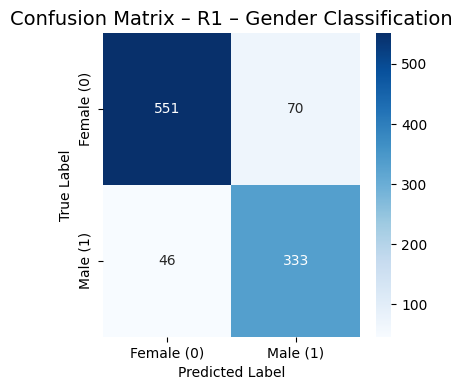


Final R1 Test Accuracy: 88.4%


In [ ]:
# ── R1: Build & train model ────────────────────────────────────────────────
# n_classes=1: single sigmoid output  (≥0.5 → Male, <0.5 → Female)
model_r1 = build_model(n_classes=1)
model_r1.summary()

EPOCHS_R1 = 5   # start with 1 during development; 5 for final results

history_r1, acc_r1, cm_r1 = train_and_evaluate(
    model_r1,
    train_gen_r1, val_gen_r1, test_gen_r1,
    class_names=['Female (0)', 'Male (1)'],
    epochs=EPOCHS_R1,
    title='R1 – Gender Classification',
    n_classes=1
)
print(f'\nFinal R1 Test Accuracy: {acc_r1:.1%}')

---
## R2 · Gender + Age Multi-Target Classification
Classify images by **both** gender (Male/Female) and age (Young/Old).
There are 4 class combinations. Report accuracy and a 4-class confusion matrix.

In [ ]:
# ── R2: Select columns  (Young attribute: 1=Young, 0=Old) ─────────────────
COLS_R2   = ['image_id', 'Male', 'Young', 'partition']
TARGET_R2 = ['Male', 'Young']    # two binary targets

df_r2 = df_full[COLS_R2].copy()

train_r2 = df_r2[df_r2['partition'] == 0]
val_r2   = df_r2[df_r2['partition'] == 1]
test_r2  = df_r2[df_r2['partition'] == 2]

TRAIN_FRAC_R2 = 0.10
train_r2 = train_r2.sample(frac=TRAIN_FRAC_R2, random_state=SEED)
val_r2   = val_r2.sample(n=1000, random_state=SEED)
test_r2  = test_r2.sample(n=1000, random_state=SEED)

print(f'R2  train={len(train_r2):,}  val={len(val_r2):,}  test={len(test_r2):,}')

# Show class combination counts
combo = train_r2.groupby(['Male','Young']).size().rename(index={0:'0',1:'1'})
print('\nClass combination counts (Male, Young):')
print(combo.rename(index={(0,0):'F+Old',(0,1):'F+Young',(1,0):'M+Old',(1,1):'M+Young'}))

R2  train=16,277  val=1,000  test=1,000

Class combination counts (Male, Young):
Male  Young
0     0        1133
      1        8303
1     0        2461
      1        4380
dtype: int64


In [ ]:
# ── R2: Data generators ────────────────────────────────────────────────────
train_gen_r2 = DataGenerator(train_r2, TARGET_R2, IMG_DIR, batch_size=32, shuffle=True)
val_gen_r2   = DataGenerator(val_r2,   TARGET_R2, IMG_DIR, batch_size=32, shuffle=False)
test_gen_r2  = DataGenerator(test_r2,  TARGET_R2, IMG_DIR, batch_size=32, shuffle=False)

print('Batch X shape:', train_gen_r2[0][0].shape)
print('Batch y shape:', train_gen_r2[0][1].shape)

Batch X shape: (32, 218, 178, 3)
Batch y shape: (32, 2)



Training: R2 – Gender + Age
Epoch 1/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 307s 602ms/step - accuracy: 0.5193 - loss: 0.5892 - val_accuracy: 0.4820 - val_loss: 0.5560
Epoch 2/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 306s 601ms/step - accuracy: 0.5427 - loss: 0.5345 - val_accuracy: 0.4970 - val_loss: 0.5134
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 306s 602ms/step - accuracy: 0.5774 - loss: 0.4990 - val_accuracy: 0.5410 - val_loss: 0.4887
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 306s 601ms/step - accuracy: 0.6128 - loss: 0.4762 - val_accuracy: 0.5830 - val_loss: 0.4678
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 306s 600ms/step - accuracy: 0.6446 - loss: 0.4581 - val_accuracy: 0.6250 - val_loss: 0.4536

Test Accuracy (R2 – Gender + Age): 65.8%


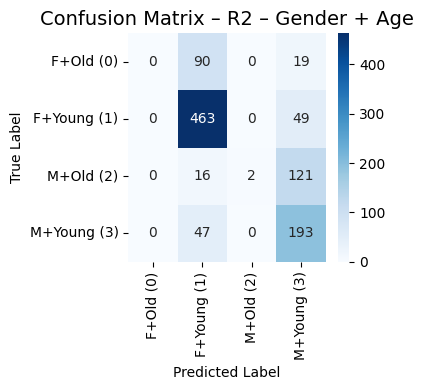


Final R2 Test Accuracy (all 4 combinations correct): 65.8%
  Per-target accuracy [Male]: 86.9%
  Per-target accuracy [Young]: 75.4%


In [ ]:
# ── R2: Build & train model (2 sigmoid outputs) ────────────────────────────
model_r2 = build_model(n_classes=2)

EPOCHS_R2 = 5

# train_and_evaluate with combine_labels=True fuses the 2-bit output into
# a single 4-class label for the confusion matrix
history_r2, acc_r2, cm_r2 = train_and_evaluate(
    model_r2,
    train_gen_r2, val_gen_r2, test_gen_r2,
    class_names=['F+Old (0)', 'F+Young (1)', 'M+Old (2)', 'M+Young (3)'],
    epochs=EPOCHS_R2,
    title='R2 – Gender + Age',
    n_classes=2,
    combine_labels=True
)

print(f'\nFinal R2 Test Accuracy (all 4 combinations correct): {acc_r2:.1%}')

# Also print per-target accuracy
y_true_r2, y_pred_r2 = get_predictions(model_r2, test_gen_r2, n_classes=2)
for idx, col in enumerate(TARGET_R2):
    t = y_true_r2[:, idx].astype(int)
    p = (y_pred_r2[:, idx] >= 0.5).astype(int)
    per_acc = (t == p).mean()
    print(f'  Per-target accuracy [{col}]: {per_acc:.1%}')

---
## R3 · Smiling Classification with Mouth-Width Metadata

**Mouth width** = `rightmouth_x − leftmouth_x` from the landmarks dataset.

- **(a)** Baseline: classify `Smiling` using image features only.
- **(b)** Augmented: classify `Smiling` using image + mouth-width quartile.
- **(c)** Analysis: does mouth-width improve accuracy?

In [ ]:
# ── R3: Compute mouth_width and assign quartile label (0-3) ────────────────
df_r3 = df_full[['image_id', 'Smiling', 'partition',
                  'leftmouth_x', 'rightmouth_x']].copy()

df_r3['mouth_width'] = df_r3['rightmouth_x'] - df_r3['leftmouth_x']

# Compute quartile labels on the FULL dataset (0=Q1, 1=Q2, 2=Q3, 3=Q4)
df_r3['mouth_width_q'] = pd.qcut(df_r3['mouth_width'], q=4,
                                  labels=[0, 1, 2, 3]).astype(int)

print(df_r3[['mouth_width', 'mouth_width_q']].describe())
print('\nQuartile counts:')
print(df_r3['mouth_width_q'].value_counts().sort_index())

# ── Partition splits ────────────────────────────────────────────────────────
train_r3 = df_r3[df_r3['partition'] == 0].sample(frac=0.10, random_state=SEED)
val_r3   = df_r3[df_r3['partition'] == 1].sample(n=1000, random_state=SEED)
test_r3  = df_r3[df_r3['partition'] == 2].sample(n=1000, random_state=SEED)

print(f'\nR3  train={len(train_r3):,}  val={len(val_r3):,}  test={len(test_r3):,}')

         mouth_width  mouth_width_q
count  202599.000000  202599.000000
mean       34.338970       1.387973
std         6.209132       1.125825
min         1.000000       0.000000
25%        30.000000       0.000000
50%        34.000000       1.000000
75%        39.000000       2.000000
max        62.000000       3.000000

Quartile counts:
mouth_width_q
0    59028
1    51253
2    47005
3    45313
Name: count, dtype: int64

R3  train=16,277  val=1,000  test=1,000



Training: R3(a) – Smiling Baseline (image only)
Epoch 1/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 305s 598ms/step - accuracy: 0.5650 - loss: 0.6908 - val_accuracy: 0.7030 - val_loss: 0.6162
Epoch 2/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 304s 597ms/step - accuracy: 0.6611 - loss: 0.6157 - val_accuracy: 0.7420 - val_loss: 0.5713
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 303s 596ms/step - accuracy: 0.7061 - loss: 0.5764 - val_accuracy: 0.7610 - val_loss: 0.5437
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 303s 596ms/step - accuracy: 0.7315 - loss: 0.5485 - val_accuracy: 0.7690 - val_loss: 0.5228
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 304s 597ms/step - accuracy: 0.7488 - loss: 0.5275 - val_accuracy: 0.7860 - val_loss: 0.5050

Test Accuracy (R3(a) – Smiling Baseline (image only)): 76.3%


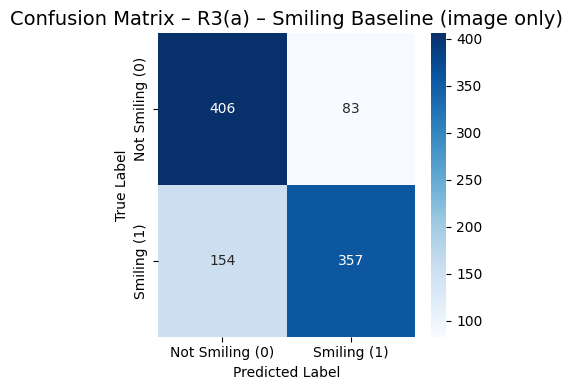


R3(a) Baseline Accuracy: 76.3%


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# R3(a): BASELINE – Smiling classification, image features only
# ════════════════════════════════════════════════════════════════════════════
TARGET_R3 = ['Smiling']

train_gen_r3a = DataGenerator(train_r3, TARGET_R3, IMG_DIR, batch_size=32, shuffle=True)
val_gen_r3a   = DataGenerator(val_r3,   TARGET_R3, IMG_DIR, batch_size=32, shuffle=False)
test_gen_r3a  = DataGenerator(test_r3,  TARGET_R3, IMG_DIR, batch_size=32, shuffle=False)

model_r3a = build_model(n_classes=1)

EPOCHS_R3 = 5

history_r3a, acc_r3a, cm_r3a = train_and_evaluate(
    model_r3a,
    train_gen_r3a, val_gen_r3a, test_gen_r3a,
    class_names=['Not Smiling (0)', 'Smiling (1)'],
    epochs=EPOCHS_R3,
    title='R3(a) – Smiling Baseline (image only)',
    n_classes=1
)
print(f'\nR3(a) Baseline Accuracy: {acc_r3a:.1%}')


Training R3(b) – dual-input model ...
Epoch 1/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 306s 601ms/step - accuracy: 0.5476 - loss: 0.6912 - val_accuracy: 0.6490 - val_loss: 0.6449
Epoch 2/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 305s 600ms/step - accuracy: 0.6488 - loss: 0.6327 - val_accuracy: 0.7050 - val_loss: 0.6027
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 305s 600ms/step - accuracy: 0.6921 - loss: 0.5974 - val_accuracy: 0.7410 - val_loss: 0.5689
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 305s 600ms/step - accuracy: 0.7225 - loss: 0.5683 - val_accuracy: 0.7550 - val_loss: 0.5430
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 306s 600ms/step - accuracy: 0.7482 - loss: 0.5457 - val_accuracy: 0.7720 - val_loss: 0.5221

R3(b) Accuracy (image + mouth_width): 74.9%


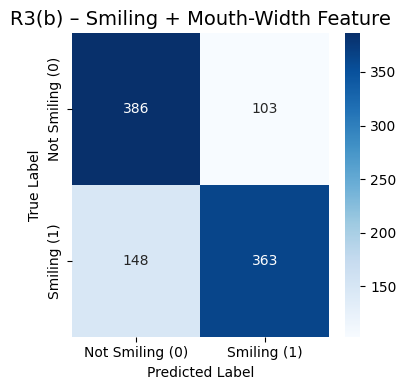

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# R3(b): AUGMENTED – Smiling classification, image + mouth_width quartile
# ════════════════════════════════════════════════════════════════════════════
META_R3 = 'mouth_width_q'

train_gen_r3b = DataGeneratorWithMeta(train_r3, TARGET_R3, META_R3, IMG_DIR,
                                       batch_size=32, shuffle=True)
val_gen_r3b   = DataGeneratorWithMeta(val_r3,   TARGET_R3, META_R3, IMG_DIR,
                                       batch_size=32, shuffle=False)
test_gen_r3b  = DataGeneratorWithMeta(test_r3,  TARGET_R3, META_R3, IMG_DIR,
                                       batch_size=32, shuffle=False)

model_r3b = build_dual_input_model(n_classes=1)

print('\nTraining R3(b) – dual-input model ...')
history_r3b = model_r3b.fit(train_gen_r3b, epochs=EPOCHS_R3,
                             validation_data=val_gen_r3b, verbose=1)

# Collect predictions
y_true_r3b, y_pred_r3b = get_predictions(model_r3b, test_gen_r3b, n_classes=1)
acc_r3b = compute_accuracy(y_true_r3b, y_pred_r3b)

y_pred_bin_r3b = (y_pred_r3b[:, 0] >= 0.5).astype(int)
cm_r3b = confusion_matrix(y_true_r3b[:, 0].astype(int), y_pred_bin_r3b)

print(f'\nR3(b) Accuracy (image + mouth_width): {acc_r3b:.1%}')
plot_confusion_matrix(cm_r3b, ['Not Smiling (0)', 'Smiling (1)'],
                      title='R3(b) – Smiling + Mouth-Width Feature')

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# R3(c): ANALYSIS – Is mouth_width a useful metadata feature?
# ════════════════════════════════════════════════════════════════════════════
print('=' * 60)
print('R3(c) – Analysis')
print('=' * 60)
print(f'Baseline accuracy  (image only)           : {acc_r3a:.1%}')
print(f'Augmented accuracy (image + mouth_width)  : {acc_r3b:.1%}')
delta = acc_r3b - acc_r3a
print(f'Improvement delta                         : {delta:+.1%}')
print()
if delta > 0.01:
    print('CONCLUSION: Adding mouth_width quartile IMPROVES smiling classification.')
    print('Interpretation: wider mouths are strongly correlated with smiling,'
          ' so this anthropometric landmark provides complementary signal'
          ' beyond the image texture captured by VGG16.')
elif delta < -0.01:
    print('CONCLUSION: Adding mouth_width quartile HURTS accuracy.')
    print('The additional feature may introduce noise or cause the model to'
          ' overfit the quartile boundaries on the small sample.')
else:
    print('CONCLUSION: mouth_width quartile provides NEGLIGIBLE benefit.')
    print('VGG16 already implicitly encodes mouth-width information from'
          ' the pixel features, so the explicit landmark measurement is'
          ' redundant.')

R3(c) – Analysis
Baseline accuracy  (image only)           : 76.3%
Augmented accuracy (image + mouth_width)  : 74.9%
Improvement delta                         : -1.4%

CONCLUSION: Adding mouth_width quartile HURTS accuracy.
The additional feature may introduce noise or cause the model to overfit the quartile boundaries on the small sample.


---
## R4 · Eye-Width Quartile Classification – Female Subset *(5215 cohort)*

**Eye width** = `righteye_x − lefteye_x` from the landmarks dataset.

- **(a)** Filter dataset to **female** individuals. Compute eye-width quartiles.
  Build two models:
  - **Model 1**: classify Q1 vs Q4 females using image only.
  - **Model 2**: classify Q1 vs Q4 females using image + eye-width feature.
- **(b)** Can eye_width predict female gender status?
- **(c)** Identify two anthropometric indexes from the dataset that could improve age classification.

In [ ]:
# ── R4: Prepare female-only data with eye_width quartiles ──────────────────
df_r4 = df_full[['image_id', 'Male', 'partition',
                  'lefteye_x', 'righteye_x']].copy()

# eye_width analogous to mouth_width
df_r4['eye_width']   = df_r4['righteye_x'] - df_r4['lefteye_x']

# Quartile labels over the FULL dataset (0=Q1, 3=Q4)
df_r4['eye_width_q'] = pd.qcut(df_r4['eye_width'], q=4,
                                labels=[0, 1, 2, 3]).astype(int)

# Filter: Female only (Male == 0)
df_r4_female = df_r4[df_r4['Male'] == 0].copy()

print(f'Total females in dataset: {len(df_r4_female):,}')
print(f'\neye_width distribution (females):')
print(df_r4_female['eye_width'].describe())

# Keep only Q1 (0) and Q4 (3) → binary classification target
df_r4_q1q4 = df_r4_female[df_r4_female['eye_width_q'].isin([0, 3])].copy()

# Re-encode: Q1 → 0, Q4 → 1  (binary target)
df_r4_q1q4['eye_q_binary'] = (df_r4_q1q4['eye_width_q'] == 3).astype(int)

print(f'\nFemales in Q1+Q4 subsets: {len(df_r4_q1q4):,}')
print(df_r4_q1q4['eye_q_binary'].value_counts()
      .rename(index={0:'Q1 (narrow)', 1:'Q4 (wide)'}))

# Partition splits
train_r4 = df_r4_q1q4[df_r4_q1q4['partition'] == 0].sample(frac=0.20, random_state=SEED)
val_r4   = df_r4_q1q4[df_r4_q1q4['partition'] == 1].sample(
               n=min(500, len(df_r4_q1q4[df_r4_q1q4['partition']==1])),
               random_state=SEED)
test_r4  = df_r4_q1q4[df_r4_q1q4['partition'] == 2].sample(
               n=min(500, len(df_r4_q1q4[df_r4_q1q4['partition']==2])),
               random_state=SEED)

print(f'\nR4  train={len(train_r4):,}  val={len(val_r4):,}  test={len(test_r4):,}')

Total females in dataset: 118,165

eye_width distribution (females):
count    118165.000000
mean         38.890018
std           3.082060
min           6.000000
25%          37.000000
50%          39.000000
75%          41.000000
max          66.000000
Name: eye_width, dtype: float64

Females in Q1+Q4 subsets: 70,976
eye_q_binary
Q4 (wide)      37348
Q1 (narrow)    33628
Name: count, dtype: int64

R4  train=11,383  val=500  test=500


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# R4(a) – MODEL 1: image only, classify Q1 vs Q4 females
# ════════════════════════════════════════════════════════════════════════════
TARGET_R4 = ['eye_q_binary']

train_gen_r4a = DataGenerator(train_r4, TARGET_R4, IMG_DIR, batch_size=32, shuffle=True)
val_gen_r4a   = DataGenerator(val_r4,   TARGET_R4, IMG_DIR, batch_size=32, shuffle=False)
test_gen_r4a  = DataGenerator(test_r4,  TARGET_R4, IMG_DIR, batch_size=32, shuffle=False)

model_r4a = build_model(n_classes=1)

EPOCHS_R4 = 5

history_r4a, acc_r4a, cm_r4a = train_and_evaluate(
    model_r4a,
    train_gen_r4a, val_gen_r4a, test_gen_r4a,
    class_names=['Q1 – Narrow Eye (0)', 'Q4 – Wide Eye (1)'],
    epochs=EPOCHS_R4,
    title='R4 Model 1 – Q1 vs Q4 Female (image only)',
    n_classes=1
)
print(f'\nR4 Model 1 Accuracy: {acc_r4a:.1%}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Training: R4 Model 1 – Q1 vs Q4 Female (image only)
Epoch 1/5
  2/356 ━━━━━━━━━━━━━━━━━━━━ 5:12:27 53s/step - accuracy: 0.5078 - loss: 0.7118

KeyboardInterrupt: 

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# R4(a) – MODEL 2: image + eye_width_q feature, classify Q1 vs Q4 females
# ════════════════════════════════════════════════════════════════════════════
META_R4 = 'eye_width_q'

train_gen_r4b = DataGeneratorWithMeta(train_r4, TARGET_R4, META_R4, IMG_DIR,
                                       batch_size=32, shuffle=True)
val_gen_r4b   = DataGeneratorWithMeta(val_r4,   TARGET_R4, META_R4, IMG_DIR,
                                       batch_size=32, shuffle=False)
test_gen_r4b  = DataGeneratorWithMeta(test_r4,  TARGET_R4, META_R4, IMG_DIR,
                                       batch_size=32, shuffle=False)

model_r4b = build_dual_input_model(n_classes=1)

print('Training R4 Model 2 – dual-input ...')
history_r4b = model_r4b.fit(train_gen_r4b, epochs=EPOCHS_R4,
                             validation_data=val_gen_r4b, verbose=1)

y_true_r4b, y_pred_r4b = get_predictions(model_r4b, test_gen_r4b, n_classes=1)
acc_r4b = compute_accuracy(y_true_r4b, y_pred_r4b)

y_pred_bin_r4b = (y_pred_r4b[:, 0] >= 0.5).astype(int)
cm_r4b = confusion_matrix(y_true_r4b[:, 0].astype(int), y_pred_bin_r4b)

print(f'\nR4 Model 2 Accuracy (image + eye_width): {acc_r4b:.1%}')
plot_confusion_matrix(cm_r4b, ['Q1 – Narrow Eye (0)', 'Q4 – Wide Eye (1)'],
                      title='R4 Model 2 – Q1 vs Q4 Female + Eye-Width Feature')

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# R4(b): ANALYSIS – Is eye_width useful for female gender classification?
# ════════════════════════════════════════════════════════════════════════════
print('=' * 60)
print('R4(b) – Analysis')
print('=' * 60)
print(f'Model 1 accuracy  (image only)         : {acc_r4a:.1%}')
print(f'Model 2 accuracy  (image + eye_width)  : {acc_r4b:.1%}')
delta_r4 = acc_r4b - acc_r4a
print(f'Improvement delta                      : {delta_r4:+.1%}')
print()
if delta_r4 > 0.01:
    print('CONCLUSION: eye_width IS a useful predictor for distinguishing'
          ' narrow-eyed (Q1) from wide-eyed (Q4) female individuals.')
    print('This suggests that women with systematically different eye widths'
          ' are visually discriminable and that the landmark measurement'
          ' provides additional signal beyond raw image texture.')
elif delta_r4 < -0.01:
    print('CONCLUSION: Adding eye_width REDUCES accuracy.')
    print('The metric may conflict with or confuse the image-derived features'
          ' learned by VGG16.')
else:
    print('CONCLUSION: eye_width provides MARGINAL benefit.')
    print('The image alone is sufficient; VGG16 implicitly captures'
          ' eye-width information from pixel-level features.')

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# R4(c): Two anthropometric indexes from CelebA that could improve
#         age (Young / Old) classification
# ════════════════════════════════════════════════════════════════════════════
print('=' * 60)
print('R4(c) – Anthropometric Indexes for Age Classification')
print('=' * 60)
analysis_text = """
Using the CelebA landmark dataset (5 landmarks: left eye, right eye,
nose, left mouth corner, right mouth corner) and the attribute data,
two anthropometric indexes can be derived and justified as useful
predictors of age (Young vs Old):

─────────────────────────────────────────────────────────────────────
INDEX 1 – Eye-to-Mouth Vertical Distance (ocular-labial distance)
─────────────────────────────────────────────────────────────────────
Computation:
    mouth_mid_y  = (leftmouth_y + rightmouth_y) / 2
    eye_mid_y    = (lefteye_y  + righteye_y)  / 2
    eye_to_mouth = mouth_mid_y - eye_mid_y

Justification:
  With age, the midface elongates due to bone resorption and soft-tissue
  descent, increasing the vertical distance from the eyes to the mouth.
  Literature in facial anthropometry (e.g. "Face Anthropometry for
  Image Recognition") identifies this ratio as one of the most
  discriminative measurements between young and old cohorts.
  In the CelebA dataset this can be directly computed from the 5
  available landmark points.

─────────────────────────────────────────────────────────────────────
INDEX 2 – Nose-to-Eye Width Ratio  (nasal-to-intercanthal index)
─────────────────────────────────────────────────────────────────────
Computation:
    eye_width        = righteye_x - lefteye_x   (intercanthal width)
    nose_offset      = abs(nose_x - (lefteye_x + righteye_x) / 2)
    nasal_eye_ratio  = nose_offset / eye_width

Justification:
  Facial fat redistribution and nasal tip descent cause the nose to
  appear wider relative to the intercanthal distance in older
  individuals. The ratio therefore increases with age. Since both the
  nose landmark and the two eye landmarks are available in CelebA, this
  index can be computed directly. It is relatively invariant to scale
  differences between images (both numerator and denominator are in the
  same coordinate system), making it a robust feature.
"""
print(analysis_text)

---
## Summary of Results

In [ ]:
print('╔══════════════════════════════════════════════════════════╗')
print('║            PROJECT 2 – RESULTS SUMMARY                  ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  R1  Gender only                    : {acc_r1:.1%}              ║')
print(f'║  R2  Gender + Age (4 combos)        : {acc_r2:.1%}              ║')
print(f'║  R3(a) Smiling baseline             : {acc_r3a:.1%}              ║')
print(f'║  R3(b) Smiling + mouth_width        : {acc_r3b:.1%}              ║')
print(f'║  R4  Q1 vs Q4 female (image only)   : {acc_r4a:.1%}              ║')
print(f'║  R4  Q1 vs Q4 female (+ eye_width)  : {acc_r4b:.1%}              ║')
print('╚══════════════════════════════════════════════════════════╝')